# Scatter plots — фича vs рост цены

Для каждой из 77 фичей показываем точечный график:
- **X** — значение фичи
- **Y** — `log(1+x_excl_top1_3h_h)` (логарифм таргета)
- Каждая точка — один из 3231 токенов

Таргет на log-шкале потому что распределение экстремально правостороннее (median 1.6, max 9300).

Под каждым графиком базовые статистики:
- **Spearman** — ранговая корреляция
- **Pearson** — линейная корреляция (на log target)
- **N** — кол-во точек
- **P95/P5** — разброс фичи

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 100

df = pd.read_csv("/tmp/b_prime_dataset_export/b_prime_training_matrix_xcont_77.csv")
TARGET = "x_excl_top1_3h_h"
features = [c for c in df.columns if c != TARGET]
y = df[TARGET].values
y_log = np.log1p(y)
print(f"Data: {df.shape}")
print(f"Features: {len(features)}")

Data: (3231, 78)
Features: 77


## Сортировка по силе сигнала

Считаем |Spearman| для каждой фичи и сортируем по убыванию — самые интересные фичи идут первыми.

In [2]:
stats_list = []
for f in features:
    x = df[f].values.astype(float)
    sp, sp_p = stats.spearmanr(x, y)
    pe, pe_p = stats.pearsonr(x, y_log)
    stats_list.append({
        'feature': f,
        'spearman': sp, 'spearman_p': sp_p,
        'pearson_log': pe, 'pearson_p': pe_p,
        'abs_sp': abs(sp),
    })
stats_df = pd.DataFrame(stats_list).sort_values('abs_sp', ascending=False).reset_index(drop=True)
print('Топ-10 фичей по силе Spearman связи с таргетом:')
print(stats_df[['feature', 'spearman', 'pearson_log']].head(10).to_string(index=False,
    float_format=lambda x: f'{x:.4f}'))

Топ-10 фичей по силе Spearman связи с таргетом:
                            feature  spearman  pearson_log
                pa_price_change_pct    0.2167       0.0101
            pa_velocity_pct_per_sec    0.2152       0.0103
top20_avg_unrealized_profit_pct_ext    0.2117       0.0175
                   pa_buy_vol_share    0.2071       0.1271
                         cutoff_cap    0.2008       0.0091
           price_sustainability_ext    0.1675       0.0338
    top20_unrealized_profit_usd_ext    0.1668       0.0092
                  pa_buy_sell_ratio    0.1534       0.0692
              top20_token_share_ext    0.1388       0.2085
                          pa_n_buys    0.1293       0.0152


## Точечные графики — все 77 фичей

Сетка 4 фичи в ряд. Под каждым графиком показаны Spearman, Pearson, и значимость.

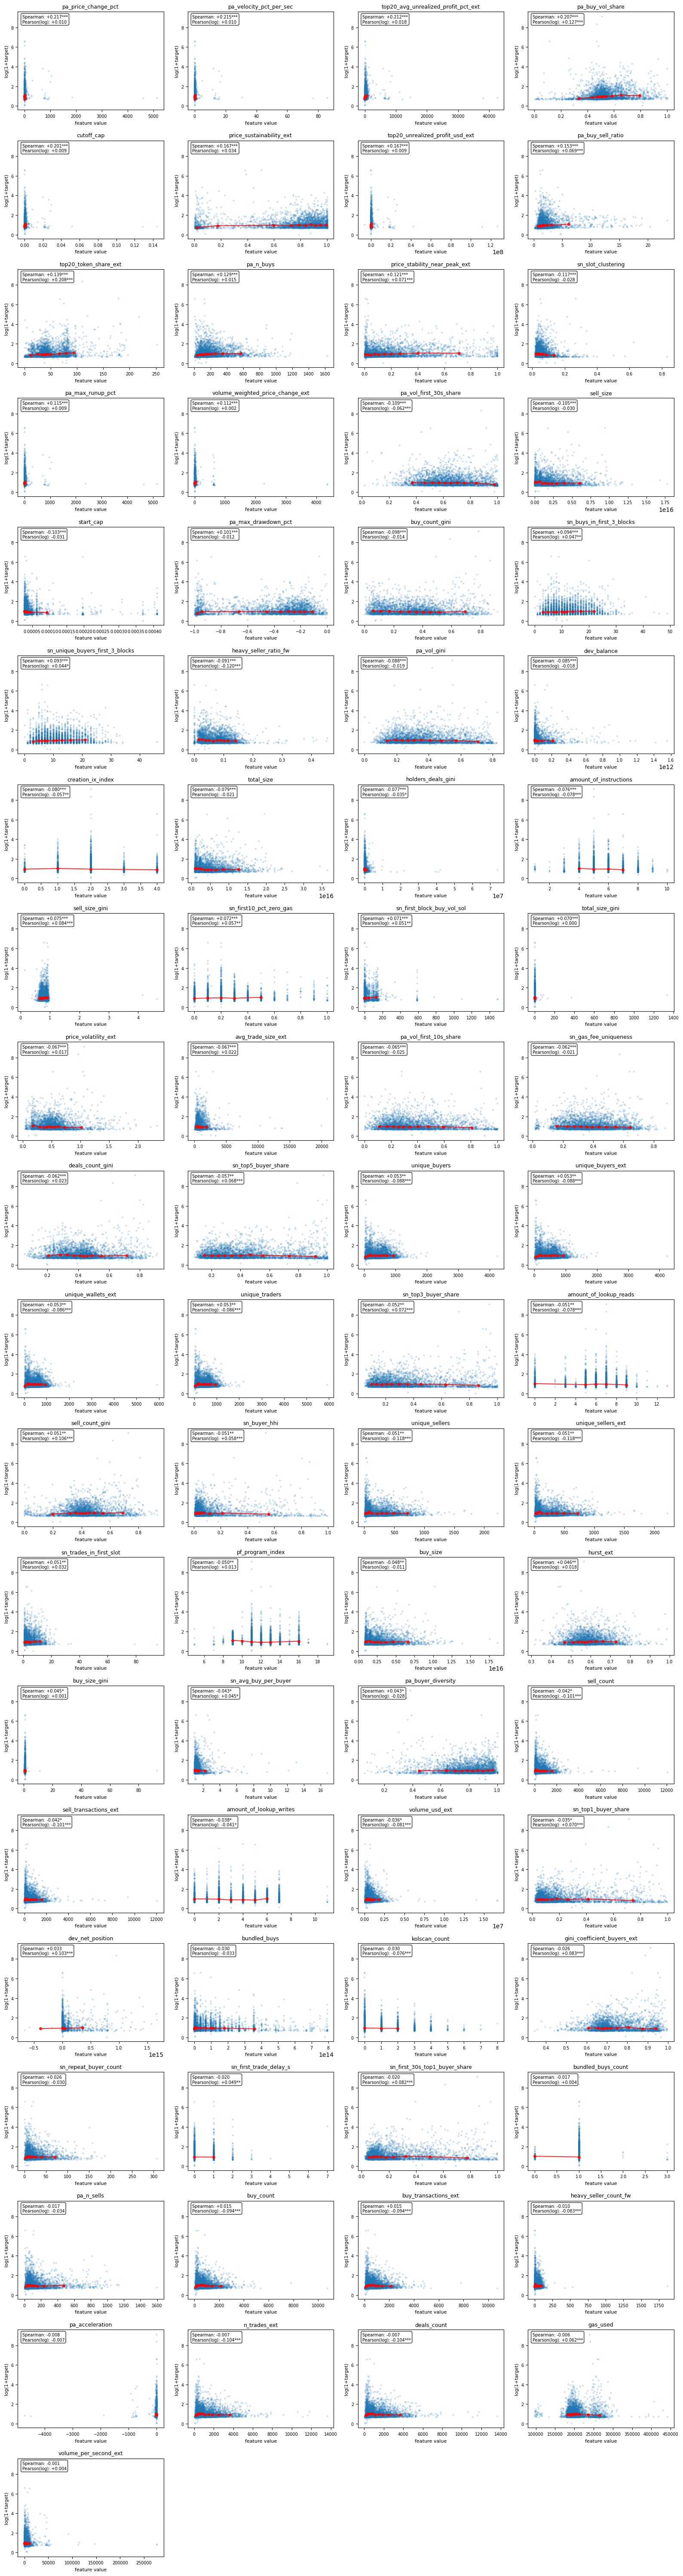

In [3]:
N_COLS = 4
features_sorted = stats_df['feature'].tolist()

# Build grid: 4 plots per row
n_rows = (len(features_sorted) + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4 * N_COLS, 3 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, feat in enumerate(features_sorted):
    r = idx // N_COLS
    c = idx % N_COLS
    ax = axes[r, c]
    x = df[feat].values.astype(float)
    sp = stats_df.iloc[idx]['spearman']
    pe = stats_df.iloc[idx]['pearson_log']
    sp_p = stats_df.iloc[idx]['spearman_p']
    pe_p = stats_df.iloc[idx]['pearson_p']
    ax.scatter(x, y_log, alpha=0.15, s=5, color='C0')
    # Add smoothed trend: decile medians
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) >= 3:
        bins = np.digitize(x, q_edges[1:-1])
        centers = []; meds = []
        for b in range(len(q_edges) - 1):
            m = bins == b
            if m.sum() == 0: continue
            centers.append(np.median(x[m]))
            meds.append(np.median(y_log[m]))
        ax.plot(centers, meds, 'r-o', alpha=0.8, markersize=4, linewidth=1.5, label='median per decile')
    ax.set_title(f'{feat}', fontsize=9)
    ax.set_xlabel('feature value', fontsize=8)
    ax.set_ylabel('log(1+target)', fontsize=8)
    # Stats annotation
    sp_sig = '***' if sp_p < 0.001 else '**' if sp_p < 0.01 else '*' if sp_p < 0.05 else ''
    pe_sig = '***' if pe_p < 0.001 else '**' if pe_p < 0.01 else '*' if pe_p < 0.05 else ''
    ax.text(0.03, 0.97, f'Spearman: {sp:+.3f}{sp_sig}\nPearson(log): {pe:+.3f}{pe_sig}',
            transform=ax.transAxes, fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.tick_params(axis='both', labelsize=7)

# Remove empty subplots
for idx in range(len(features_sorted), n_rows * N_COLS):
    r = idx // N_COLS; c = idx % N_COLS
    fig.delaxes(axes[r, c])

plt.tight_layout()
plt.savefig('/tmp/feature_research/all_scatter.png', dpi=110, bbox_inches='tight')
plt.show()

## Таблица всех статистик

In [4]:
stats_df.drop(columns='abs_sp').to_csv(
    '/tmp/feature_research/scatter_stats.csv', index=False)
print('Сохранил /tmp/feature_research/scatter_stats.csv')
print(f'\nВсего фичей: {len(stats_df)}')
print(f'Со значимым Spearman p<0.001: {(stats_df["spearman_p"] < 0.001).sum()}')
print(f'Со значимым Spearman p<0.01:  {(stats_df["spearman_p"] < 0.01).sum()}')
print(f'Со значимым Spearman p<0.05:  {(stats_df["spearman_p"] < 0.05).sum()}')
stats_df.drop(columns='abs_sp')

Сохранил /tmp/feature_research/scatter_stats.csv

Всего фичей: 77
Со значимым Spearman p<0.001: 37
Со значимым Spearman p<0.01:  52
Со значимым Spearman p<0.05:  60


,feature,spearman,spearman_p,pearson_log,pearson_p
0,pa_price_change_pct,0.216708,1.207648e-35,0.010139,5.645432e-01
1,pa_velocity_pct_per_sec,0.215210,3.636701e-35,0.010312,5.579005e-01
2,top20_avg_unrealized_profit_pct_ext,0.211736,4.544477e-34,0.017532,3.191415e-01
3,pa_buy_vol_share,0.207101,1.231895e-32,0.127072,4.179429e-13
4,cutoff_cap,0.200757,9.929983e-31,0.009113,6.045997e-01
...,...,...,...,...,...
72,pa_acceleration,-0.007741,6.600621e-01,-0.007042,6.890567e-01
73,n_trades_ext,-0.006855,6.969208e-01,-0.103796,3.345537e-09
74,deals_count,-0.006855,6.969208e-01,-0.103796,3.345537e-09
75,gas_used,-0.005958,7.349608e-01,0.062199,4.037947e-04


## Интерпретация графиков

### Как читать?
- **Красная линия** — медиана log(target) по децилям фичи. Показывает "тренд" проще чем облако точек.
- **Spearman** — ранговая корреляция. Устойчива к выбросам. Чем больше |значение|, тем сильнее связь.
- **Pearson(log)** — линейная корреляция на log-шкале. Чувствительна к форме кривой.
- `***` = p<0.001, `**` = p<0.01, `*` = p<0.05 — значимость. Без звёзд — связь может быть случайной.

### На что обращать внимание
- **Прямая наклонная красная линия** → монотонная связь
- **U-образная красная линия** → нелинейная зависимость
- **Плоская красная линия** → фича ничего не говорит
- **Облако точек разбросано в широком диапазоне** → даже при значимой корреляции предсказание одной фичей неточное